In [2]:
from google.colab import files
uploaded = files.upload()  # Upload intents.json

Saving intents.json to intents.json


In [3]:
pip install nltk tensorflow numpy

In [4]:
import nltk
import json
import numpy as np
import random
import pickle

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
with open('intents.json') as f:
    intents = json.load(f)

print(f"Total intents: {len(intents['intents'])}")
for intent in intents['intents']:
    print(f"Tag: {intent['tag']} | Patterns: {len(intent['patterns'])}")

Total intents: 38
Tag: greeting | Patterns: 10
Tag: goodbye | Patterns: 12
Tag: creator | Patterns: 16
Tag: name | Patterns: 13
Tag: hours | Patterns: 17
Tag: number | Patterns: 15
Tag: course | Patterns: 27
Tag: fees | Patterns: 23
Tag: location | Patterns: 14
Tag: hostel | Patterns: 22
Tag: event | Patterns: 11
Tag: document | Patterns: 13
Tag: floors | Patterns: 7
Tag: syllabus | Patterns: 7
Tag: library | Patterns: 14
Tag: infrastructure | Patterns: 3
Tag: canteen | Patterns: 11
Tag: menu | Patterns: 7
Tag: placement | Patterns: 9
Tag: ithod | Patterns: 4
Tag: computerhod | Patterns: 4
Tag: extchod | Patterns: 4
Tag: principal | Patterns: 7
Tag: sem | Patterns: 11
Tag: admission | Patterns: 6
Tag: scholarship | Patterns: 26
Tag: facilities | Patterns: 5
Tag: college intake | Patterns: 9
Tag: uniform | Patterns: 9
Tag: committee | Patterns: 6
Tag: random | Patterns: 3
Tag: swear | Patterns: 9
Tag: vacation | Patterns: 12
Tag: sports | Patterns: 7
Tag: salutaion | Patterns: 13
Tag: t

In [6]:
words = []
classes = []
documents = []
ignore_chars = ['?', '!', '.', ',']

for intent in intents['intents']:
    for pattern in intent['patterns']:
        word_list = nltk.word_tokenize(pattern)
        words.extend(word_list)
        documents.append((word_list, intent['tag']))
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

# Lemmatize and clean words
words = [lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore_chars]
words = sorted(set(words))
classes = sorted(set(classes))

print(f"Unique words: {len(words)}")
print(f"Classes (intents): {len(classes)}")
print(f"Documents: {len(documents)}")

# Save for later use
pickle.dump(words, open('words.pkl', 'wb'))
pickle.dump(classes, open('classes.pkl', 'wb'))

Unique words: 263
Classes (intents): 38
Documents: 405


In [7]:
training = []
output_empty = [0] * len(classes)

for document in documents:
    bag = []
    word_patterns = [lemmatizer.lemmatize(w.lower()) for w in document[0]]

    for word in words:
        bag.append(1 if word in word_patterns else 0)

    output_row = list(output_empty)
    output_row[classes.index(document[1])] = 1
    training.append([bag, output_row])

random.shuffle(training)
training = np.array(training, dtype=object)

X_train = np.array(list(training[:, 0]))
y_train = np.array(list(training[:, 1]))

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (405, 263)
y_train shape: (405, 38)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

model = Sequential()
model.add(Dense(128, input_shape=(len(X_train[0]),), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(y_train[0]), activation='softmax'))

sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,518 (173.90 KB)

 Trainable params: 44,518 (173.90 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=5,
    verbose=1
)

model.save('chatbot_model.h5')
print("✅ Model saved!")

Epoch 1/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0395 - loss: 3.6196
Epoch 2/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1185 - loss: 3.4504
Epoch 3/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1654 - loss: 3.2516
Epoch 4/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2395 - loss: 2.9587
Epoch 5/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2815 - loss: 2.6633
Epoch 6/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3630 - loss: 2.4528
Epoch 7/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4074 - loss: 2.2087
Epoch 8/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4790 - loss: 1.9392
Epoch 9/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5185 - loss: 1.8506
Epoch 10/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5654 - loss: 1.6671
Epoch 11/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5926 - loss: 1.4992
Epoch 12/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

✅ Model saved!


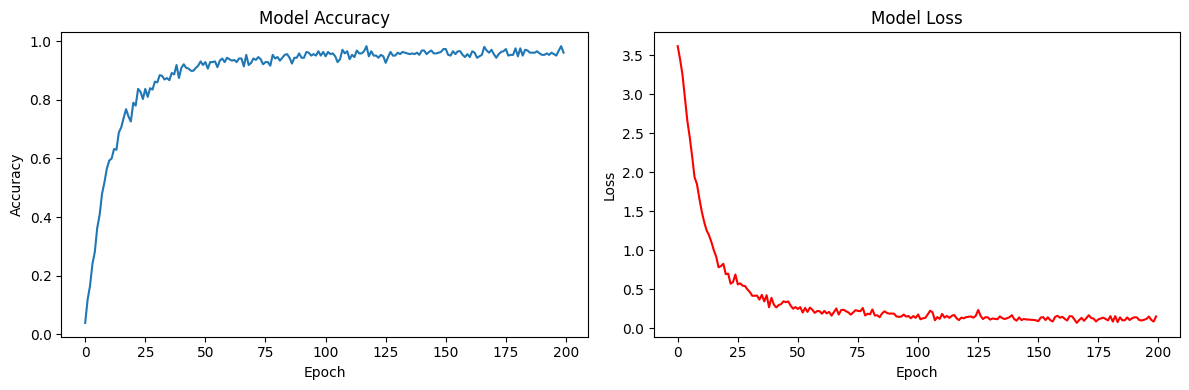

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras.models import load_model

model = load_model('chatbot_model.h5')
words = pickle.load(open('words.pkl', 'rb'))
classes = pickle.load(open('classes.pkl', 'rb'))

def clean_up_sentence(sentence):
    sentence_words = nltk.word_tokenize(sentence)
    sentence_words = [lemmatizer.lemmatize(w.lower()) for w in sentence_words]
    return sentence_words

def bag_of_words(sentence):
    sentence_words = clean_up_sentence(sentence)
    bag = [1 if w in sentence_words else 0 for w in words]
    return np.array(bag)

def predict_class(sentence):
    bow = bag_of_words(sentence)
    result = model.predict(np.array([bow]), verbose=0)[0]
    ERROR_THRESHOLD = 0.25
    results = [[i, r] for i, r in enumerate(result) if r > ERROR_THRESHOLD]
    results.sort(key=lambda x: x[1], reverse=True)
    return [{'intent': classes[r[0]], 'probability': str(r[1])} for r in results]

def get_response(intents_list, intents_json):
    if not intents_list:
        return "I'm sorry, I didn't understand that. Can you rephrase?"
    tag = intents_list[0]['intent']
    for intent in intents_json['intents']:
        if intent['tag'] == tag:
            return random.choice(intent['responses'])
    return "I'm not sure how to respond to that."

print("✅ Chatbot functions ready!")

✅ Chatbot functions ready!


In [12]:
# Test single responses
test_inputs = ["Hello", "What are the fees?", "Where is the college?", "Goodbye"]

for msg in test_inputs:
    intents_list = predict_class(msg)
    response = get_response(intents_list, intents)
    print(f"You: {msg}")
    print(f"Bot: {response}\n")

You: Hello
Bot: Good to see you again!

You: What are the fees?
Bot: For Fee detail visit <a target="_blank" href="LINK"> here</a>

You: Where is the college?
Bot: <a target="_blank" href="ADD YOU GOOGLE MAP LINK HERE"> here</a>

You: Goodbye
Bot: Sad to see you go :(



In [15]:
print("🤖 College Chatbot is ready! Type 'quit' to exit.\n")

while True:
    user_input = input("You: ")
    if user_input.lower() in ['quit', 'exit', 'bye']:
        print("Bot: Goodbye! Have a great day!")
        break
    intents_list = predict_class(user_input)
    response = get_response(intents_list, intents)
    print(f"Bot: {response}\n")

🤖 College Chatbot is ready! Type 'quit' to exit.

You: hi
Bot: Hello!

You: bye
Bot: Goodbye! Have a great day!


In [16]:
files.download('chatbot_model.h5')
files.download('words.pkl')
files.download('classes.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>